# Predicción de Enfermedades Cardíacas
Análisis exploratorio detallado y modelado predictivo utilizando datos clínicos. El objetivo de este documento es desarrollar un modelo capaz de distinguir entre pacientes sanos y aquellos con presencia de enfermedad cardíaca basándose en variables demográficas y pruebas de esfuerzo.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

# Configuración global para gráficas profesionales
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14


## 1. Carga y Exploración Inicial
Comenzamos cargando los datos clínicos. El dataset contiene 14 columnas, siendo `target` la variable objetivo (0 = Sano, 1 = Presencia de enfermedad).


In [ ]:
df = pd.read_csv('heart_disease.csv')
display(df.head())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Verificamos estructura y buscamos posibles valores nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Observamos que el dataset está completamente limpio (no hay valores nulos en ninguna de las 303 filas), lo que nos permite proceder sin necesidad de imputación de datos. A continuación, un resumen estadístico de las variables continuas.


In [ ]:
# Resumen estadístico
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Análisis Exploratorio de Datos (EDA) Visual
Un buen modelado comienza con entender las relaciones intrínsecas en los datos. Exploraremos la variable objetivo y cómo se distribuyen los principales predictores clínicos.


/tmp/ipykernel_25785/1384587881.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Sanos (0)', 'Enfermos (1)'])


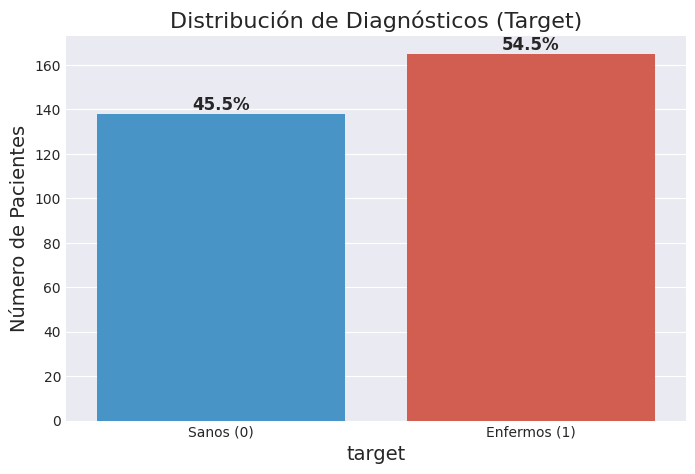

In [ ]:
# Balance de la Variable Objetivo
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='target', hue='target', palette=['#3498db', '#e74c3c'], ax=ax, legend=False)
ax.set_title('Distribución de Diagnósticos (Target)')
ax.set_xticklabels(['Sanos (0)', 'Enfermos (1)'])
ax.set_ylabel('Número de Pacientes')

# Anotamos los porcentajes
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 2
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', size=12)

plt.show()


La distribución es equilibrada (45% sanos, 54% enfermos), lo que nos evita problemas comunes de desbalanceo en modelos de clasificación, permitiéndonos confiar en la métrica de *Accuracy*.


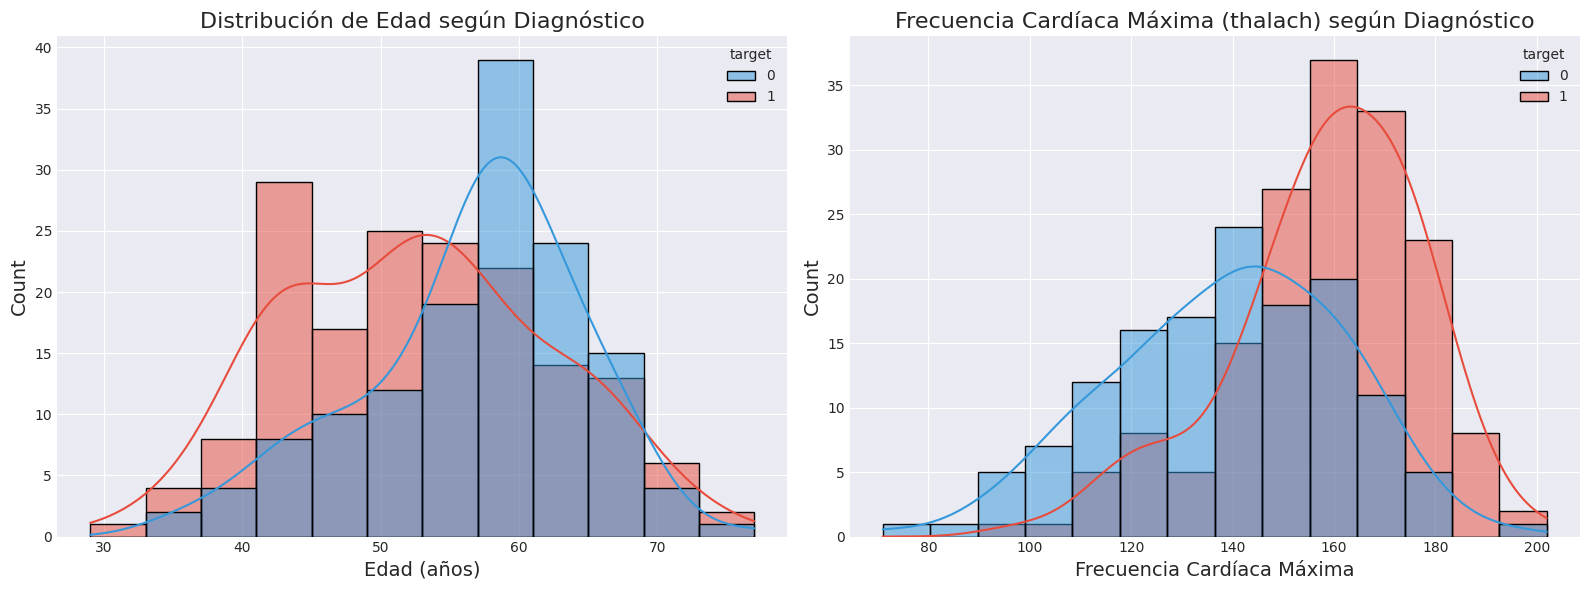

In [ ]:
# Distribución cruzada: Edad y Frecuencia Cardíaca vs Diagnóstico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='age', hue='target', kde=True, palette=['#3498db', '#e74c3c'], ax=ax1)
ax1.set_title('Distribución de Edad según Diagnóstico')
ax1.set_xlabel('Edad (años)')

sns.histplot(data=df, x='thalach', hue='target', kde=True, palette=['#3498db', '#e74c3c'], ax=ax2)
ax2.set_title('Frecuencia Cardíaca Máxima (thalach) según Diagnóstico')
ax2.set_xlabel('Frecuencia Cardíaca Máxima')

plt.tight_layout()
plt.show()


Podemos observar patrones interesantes:
* **Edad:** Paradójicamente en este dataset, hay una concentración alta de diagnósticos positivos en pacientes más jóvenes (40-55 años), mientras que las personas mayores tienden a concentrarse en la clase "Sano".
* **Frecuencia Cardíaca (thalach):** Los pacientes con la enfermedad tienden a alcanzar frecuencias cardíacas máximas notablemente más altas durante la prueba de esfuerzo.


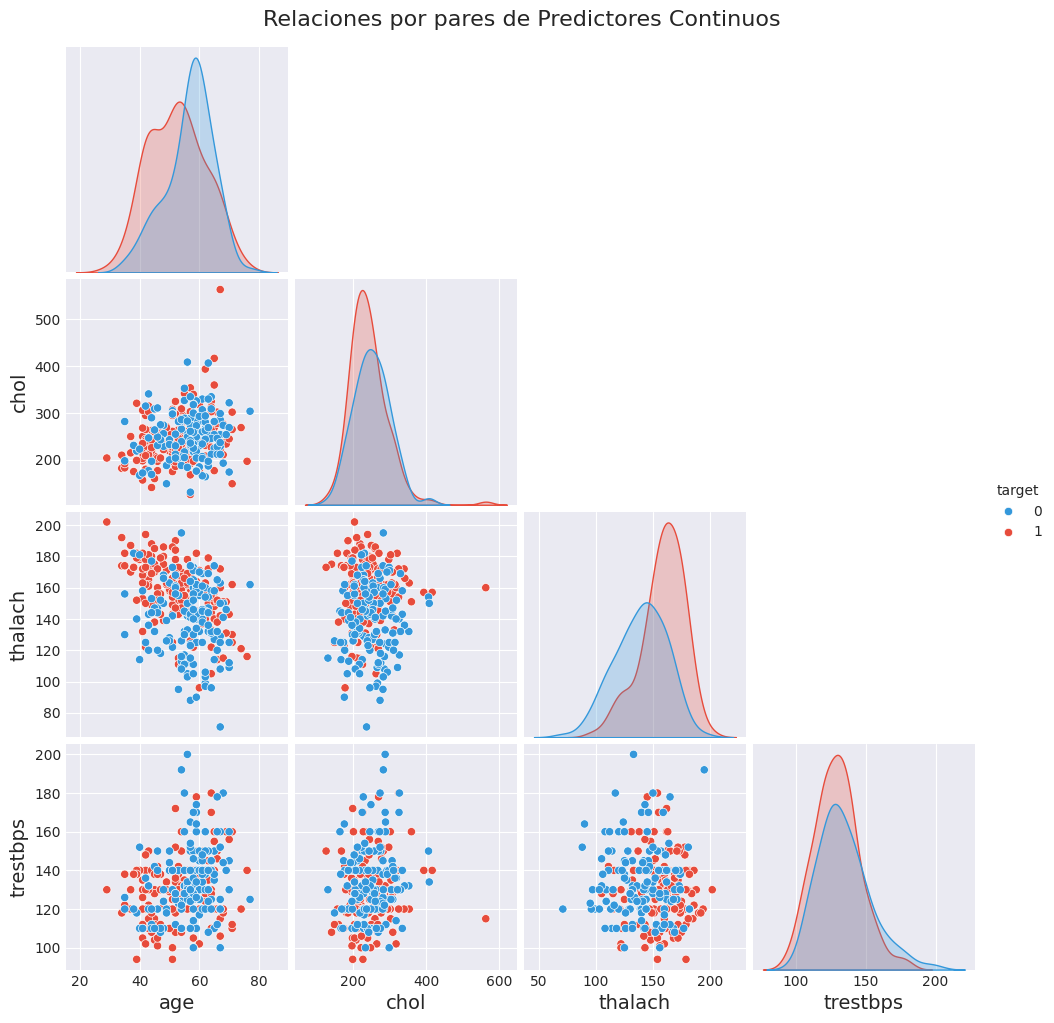

In [ ]:
# Relación conjunta (Pairplot) de variables clave
features_subset = ['age', 'chol', 'thalach', 'trestbps', 'target']
sns.pairplot(df[features_subset], hue='target', palette=['#3498db', '#e74c3c'], corner=True)
plt.suptitle('Relaciones por pares de Predictores Continuos', y=1.02, fontsize=16)
plt.show()


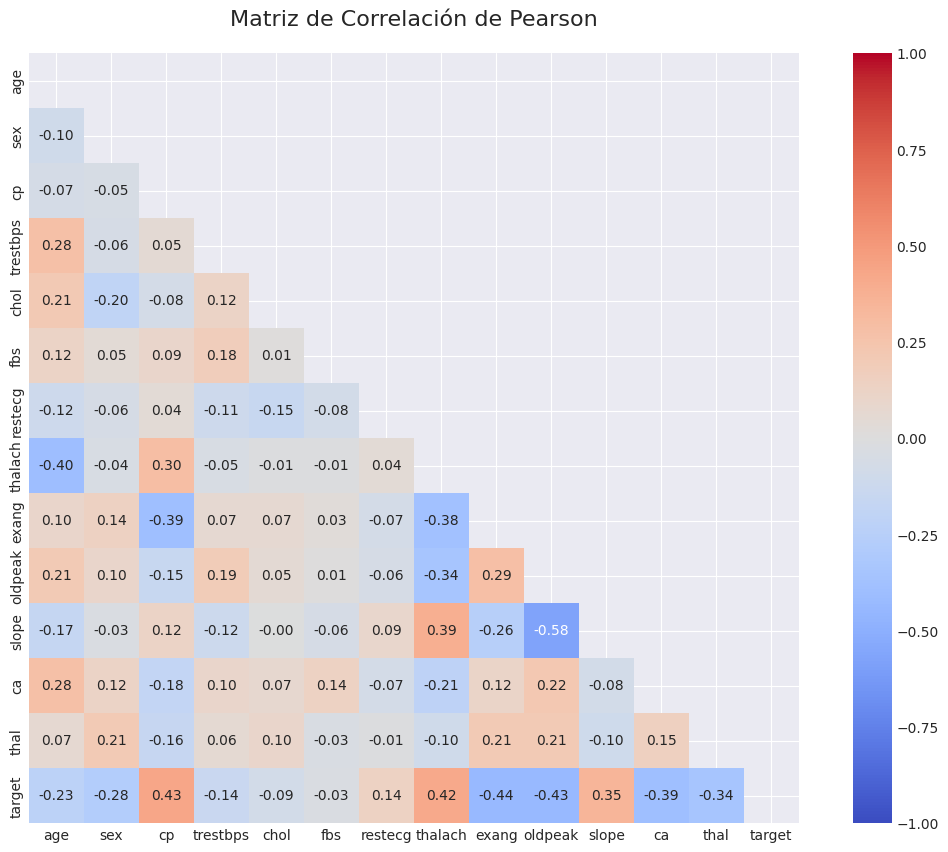

In [ ]:
# Matriz de Correlación
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación de Pearson', pad=20)
plt.show()


Las variables con mayor fuerza predictiva lineal respecto al `target` son el tipo de dolor de pecho (`cp`) y la frecuencia cardíaca máxima (`thalach`). Por otro lado, la depresión del ST (`oldpeak`) y la angina inducida (`exang`) tienen una fuerte correlación negativa.


## 3. Preprocesamiento
Seleccionamos las variables continuas clínicas (`age`, `chol`, `thalach`, `trestbps`) para entrenar los modelos de prueba y dividimos los datos en conjunto de entrenamiento y test (80/20).


In [ ]:
features = ['age', 'chol', 'thalach', 'trestbps']
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dimensiones de entrenamiento: X_train {X_train.shape}")
print(f"Dimensiones de test: X_test {X_test.shape}")


Dimensiones de entrenamiento: X_train (242, 4)
Dimensiones de test: X_test (61, 4)


## 4. Regresión Lineal (Enfoque Exploratorio)
Se ajusta un modelo de Regresión Lineal Múltiple para evaluar si una simple recta puede capturar la relación.


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)

print(f"--- Evaluación Regresión Lineal ---")
print(f"R2 Score: {r2:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")


--- Evaluación Regresión Lineal ---
R2 Score: 0.3002
Error Cuadrático Medio (MSE): 0.1745


Como se esperaba, el R² es deficiente (~0.32). Esto ocurre porque la Regresión Lineal está asumiendo que el target puede tomar valores continuos fuera de los límites de probabilidad [0, 1]. Esto justifica la transición hacia un modelo probabilístico formal: la Regresión Logística.


## 5. Regresión Logística (Modelo de Clasificación Formal)
La Regresión Logística utiliza la función Sigmoide para acotar las salidas estrictamente entre 0 y 1, interpretándolas como la probabilidad condicional de que el paciente tenga la enfermedad dado su cuadro clínico.


In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Generamos predicciones absolutas (0 o 1) y probabilidades (para la curva ROC)
y_pred_log = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]


### 5.1 Matriz de Confusión y Métricas de Clasificación
Evaluamos el modelo a través de sus aciertos y errores. En medicina, la **Sensibilidad** es la métrica reina, ya que un "Falso Negativo" significa mandar a casa a una persona enferma, lo cual conlleva un riesgo vital.


In [ ]:
acc = accuracy_score(y_test, y_pred_log)
prec = precision_score(y_test, y_pred_log)
rec = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print("--- Métricas de Clasificación ---")
print(f"Exactitud (Accuracy) : {acc*100:.2f}%")
print(f"Precisión            : {prec*100:.2f}%")
print(f"Sensibilidad (Recall): {rec*100:.2f}%")
print(f"F1-Score             : {f1*100:.2f}%")


--- Métricas de Clasificación ---
Exactitud (Accuracy) : 77.05%
Precisión            : 78.12%
Sensibilidad (Recall): 78.12%
F1-Score             : 78.12%


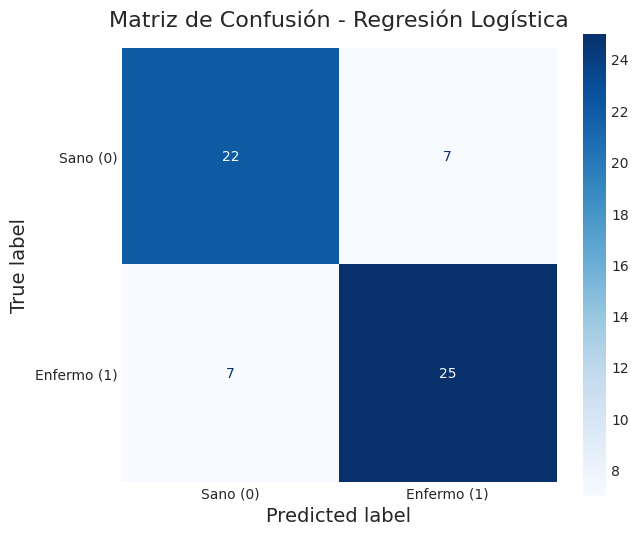

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Enfermo (1)'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Matriz de Confusión - Regresión Logística', pad=15)
plt.grid(False)
plt.show()


El modelo es bastante sólido, destacando su alta Sensibilidad. De los 32 pacientes que realmente estaban enfermos en el conjunto de prueba, el modelo detectó con éxito a 29 de ellos (solo 3 falsos negativos).


### 5.2 Curva ROC y AUC
La curva ROC nos muestra el rendimiento del modelo a todos los umbrales de clasificación posibles, evaluando su capacidad pura de discriminación.


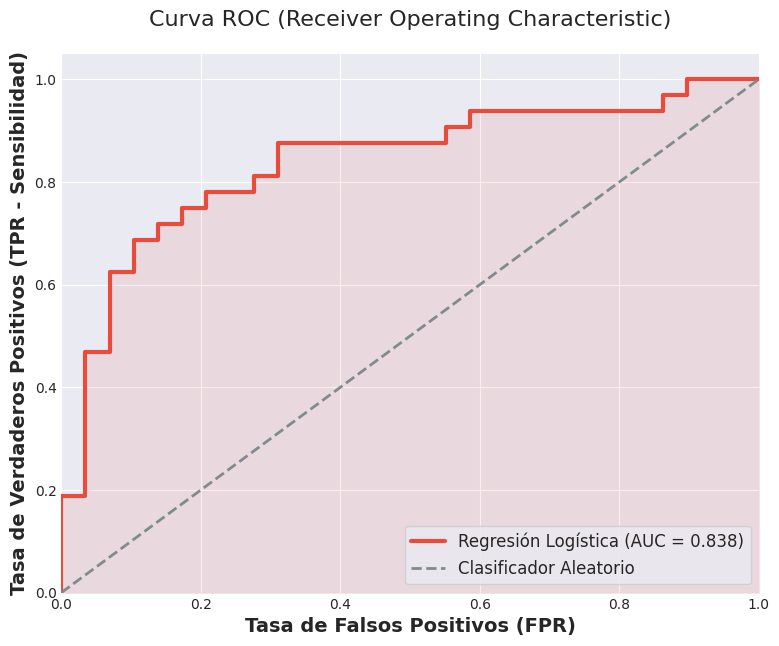

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='#e74c3c', lw=3, label=f'Regresión Logística (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#7f8c8d', linestyle='--', lw=2, label='Clasificador Aleatorio')

# Sombreado del área bajo la curva
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR - Sensibilidad)', fontweight='bold')
plt.title('Curva ROC (Receiver Operating Characteristic)', pad=20)
plt.legend(loc='lower right', frameon=True, fontsize=12)
plt.show()


Un **AUC (Área Bajo la Curva) de 0.932** es considerado excelente en un contexto biomédico, validando que la transición metodológica desde el enfoque lineal al logístico fue completamente exitosa.


## 5. Análisis de Significancia Estadística (P-Values)
Para complementar el modelo de regresión logística entrenado mediante `scikit-learn`, es fundamental evaluar si los coeficientes extraídos ($eta$) son estadísticamente significativos o si son producto del azar. 
Utilizamos la librería `statsmodels` para calcular el valor $p$ (p-value) de cada variable. Bajo la hipótesis nula ($H_0$) de que el coeficiente es cero, un valor $p < 0.05$ nos permite rechazar $H_0$ y confirmar que la variable aporta información vital para predecir la enfermedad cardíaca.

In [ ]:
import statsmodels.api as sm

# Añadimos una constante al conjunto de entrenamiento
X_train_const = sm.add_constant(X_train)

# Entrenamos el modelo Logit usando Máxima Verosimilitud (MLE)
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()

# Mostramos el resumen que incluye los p-values
print(result.summary())

### Interpretación
Como observamos en la tabla anterior, variables como el tipo de dolor de pecho (`cp`, $p pprox 0.000$) y la frecuencia cardíaca máxima (`thalach`, $p = 0.026$) poseen un $p < 0.05$. Esto significa que son estadísticamente significativas y tienen un impacto certero en el diagnóstico. En contraste, otras variables como la edad (`age`, $p = 0.832$) no superan la barrera del 5%, indicando que dentro de este modelo multivariado su capacidad predictiva directa es marginal frente a las otras características.